In [2]:
!pip -q install pandas numpy scikit-learn xgboost sentence-transformers statsmodels matplotlib openpyxl joblib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
INPUT_DIR = f"{PROJECT_ROOT}/input"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"
MODEL_DIR = f"{PROJECT_ROOT}/models"

for path in [PROJECT_ROOT, INPUT_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(path, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input dir:", INPUT_DIR)
print("Output dir:", OUTPUT_DIR)
print("Model dir:", MODEL_DIR)
print("\nDrop all subreddit CSVs into the input folder, then run the next cell.")

Mounted at /content/drive
Project root: /content/drive/MyDrive/reddit_ai_study
Input dir: /content/drive/MyDrive/reddit_ai_study/input
Output dir: /content/drive/MyDrive/reddit_ai_study/output
Model dir: /content/drive/MyDrive/reddit_ai_study/models

Drop all subreddit CSVs into the input folder, then run the next cell.


In [4]:
import os
import re
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

from sentence_transformers import SentenceTransformer
import statsmodels.formula.api as smf
import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

KINDS = [
    "anchor_posts_removed_meta",
    "comments_removed_meta_threads",
    "comments_clean_final",
    "comments_raw",
    "comment_exclusions",
    "comment_templates_removed",
    "to_label_balanced",
    "to_label_overlap",
    "weekly_summary",
    "anchor_posts",
]

KIND_PATTERN = "|".join(sorted(KINDS, key=len, reverse=True))
FILE_RE = re.compile(
    rf"^(?P<subreddit>.+?)_(?P<kind>{KIND_PATTERN})_(?P<start>\d{{8}})_(?P<end>\d{{8}})_(?P<tag>.+)\.csv$",
    flags=re.IGNORECASE,
)

def build_manifest(input_dir: str) -> pd.DataFrame:
    rows = []
    for path in sorted(glob.glob(os.path.join(input_dir, "*.csv"))):
        name = os.path.basename(path)
        m = FILE_RE.match(name)
        if not m:
            continue
        info = m.groupdict()
        info["path"] = path
        info["filename"] = name
        info["batch_id"] = f"{info['subreddit']}__{info['start']}__{info['end']}__{info['tag']}"
        rows.append(info)

    manifest = pd.DataFrame(rows)
    if manifest.empty:
        raise FileNotFoundError(
            f"No matching CSV files found in {input_dir}.\n"
            "Expected names like: askscience_comments_clean_final_20251006_20251228_weekbalanced.csv"
        )

    manifest = manifest.sort_values(
        ["subreddit", "start", "end", "tag", "kind"]
    ).reset_index(drop=True)
    return manifest

def load_batches_from_manifest(manifest: pd.DataFrame) -> dict:
    batches = {}
    for batch_id, group in manifest.groupby("batch_id"):
        first = group.iloc[0].to_dict()
        batch = {
            "meta": {
                "batch_id": batch_id,
                "subreddit": first["subreddit"],
                "window_start": first["start"],
                "window_end": first["end"],
                "tag": first["tag"],
            },
            "tables": {},
        }
        for _, row in group.iterrows():
            batch["tables"][row["kind"]] = pd.read_csv(row["path"], low_memory=False)
        batches[batch_id] = batch
    return batches

def safe_len(df):
    return int(len(df)) if isinstance(df, pd.DataFrame) else np.nan

def get_valid_group_split(y, groups, test_size=0.2, max_tries=50):
    for seed in range(1, max_tries + 1):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        train_idx, test_idx = next(gss.split(np.zeros(len(y)), y, groups=groups))
        y_train = y[train_idx]
        y_test = y[test_idx]
        if len(np.unique(y_train)) >= 2 and len(np.unique(y_test)) >= 2:
            return train_idx, test_idx
    raise ValueError(
        "Could not find a valid grouped train/test split with both classes in train and test. "
        "You likely need more labeled examples in both classes."
    )

manifest = build_manifest(INPUT_DIR)
manifest.to_csv(f"{OUTPUT_DIR}/manifest.csv", index=False)

print("Files found:")
display(manifest[["subreddit", "kind", "start", "end", "tag", "filename"]])
print("\nSaved manifest to:", f"{OUTPUT_DIR}/manifest.csv")

Files found:


,subreddit,kind,start,end,tag,filename
0,Advice,anchor_posts,20251006,20251228,weekbalanced,Advice_anchor_posts_20251006_20251228_weekbalanced.csv
1,Advice,anchor_posts_removed_meta,20251006,20251228,weekbalanced,Advice_anchor_posts_removed_meta_20251006_20251228_weekbalanced.csv
2,Advice,comment_exclusions,20251006,20251228,weekbalanced,Advice_comment_exclusions_20251006_20251228_weekbalanced.csv
3,Advice,comment_templates_removed,20251006,20251228,weekbalanced,Advice_comment_templates_removed_20251006_20251228_weekbalanced.csv
4,Advice,comments_clean_final,20251006,20251228,weekbalanced,Advice_comments_clean_final_20251006_20251228_weekbalanced.csv
5,Advice,comments_raw,20251006,20251228,weekbalanced,Advice_comments_raw_20251006_20251228_weekbalanced.csv
6,Advice,comments_removed_meta_threads,20251006,20251228,weekbalanced,Advice_comments_removed_meta_threads_20251006_20251228_weekbalanced.csv
7,Advice,to_label_balanced,20251006,20251228,weekbalanced,Advice_to_label_balanced_20251006_20251228_weekbalanced.csv
8,Advice,to_label_overlap,20251006,20251228,weekbalanced,Advice_to_label_overlap_20251006_20251228_weekbalanced.csv
9,Advice,weekly_summary,20251006,20251228,weekbalanced,Advice_weekly_summary_20251006_20251228_weekbalanced.csv



Saved manifest to: /content/drive/MyDrive/reddit_ai_study/output/manifest.csv


Batch audit:


,batch_id,subreddit,window_start,window_end,tag,raw_comments,excluded_comments,template_removed_comments,meta_removed_comments,final_clean_comments,retention_pct,anchor_posts,posts_with_retained_comments,comment_to_comment_replies,direct_post_replies,reply_chain_share_pct,parent_post_found_rate_pct,weeks_present
0,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,weekbalanced,3600,93,1,0.0,2498,69.39,917,765,435,2063,17.41,92.95,12
1,AskDocs__20251006__20251228__weekbalanced,AskDocs,20251006,20251228,weekbalanced,6100,2834,3,42.0,1572,25.77,977,596,819,753,52.10,97.33,12
2,askscience__20251006__20251228__weekbalanced,askscience,20251006,20251228,weekbalanced,6600,3287,2,NaN,2541,38.50,190,153,1744,797,68.63,100.00,12
3,todayilearned__20251006__20251228__weekbalanced,todayilearned,20251006,20251228,weekbalanced,3600,122,1,3.0,995,27.64,371,230,213,782,21.41,92.26,12



Combined clean corpus shape: (7606, 23)
Combined weekly summary shape: (48, 12)


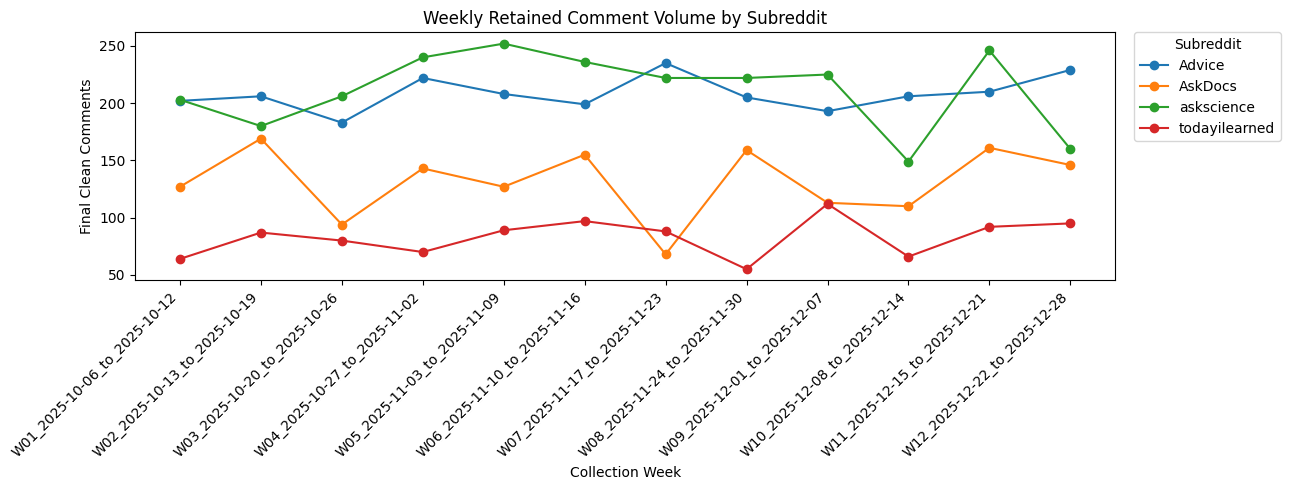


Saved:
/content/drive/MyDrive/reddit_ai_study/output/batch_audit.csv
/content/drive/MyDrive/reddit_ai_study/output/combined_comments_clean_final.csv
/content/drive/MyDrive/reddit_ai_study/output/combined_weekly_summary.csv
/content/drive/MyDrive/reddit_ai_study/output/weekly_retained_comment_volume.png


In [16]:
batches = load_batches_from_manifest(manifest)

audit_rows = []
combined_clean_parts = []
combined_weekly_parts = []

for batch_id, batch in batches.items():
    meta = batch["meta"]
    tables = batch["tables"]

    raw_df = tables.get("comments_raw")
    clean_df = tables.get("comments_clean_final")
    anchor_df = tables.get("anchor_posts")
    weekly_df = tables.get("weekly_summary")
    exclusions_df = tables.get("comment_exclusions")
    template_df = tables.get("comment_templates_removed")
    removed_meta_df = tables.get("comments_removed_meta_threads")

    row = dict(meta)
    row["raw_comments"] = safe_len(raw_df)
    row["excluded_comments"] = safe_len(exclusions_df)
    row["template_removed_comments"] = safe_len(template_df)
    row["meta_removed_comments"] = safe_len(removed_meta_df)
    row["final_clean_comments"] = safe_len(clean_df)
    row["retention_pct"] = round(
        100 * row["final_clean_comments"] / row["raw_comments"], 2
    ) if row["raw_comments"] else np.nan
    row["anchor_posts"] = safe_len(anchor_df)

    if isinstance(clean_df, pd.DataFrame) and not clean_df.empty:
        row["posts_with_retained_comments"] = int(clean_df["post_id"].nunique())
        row["comment_to_comment_replies"] = int(clean_df["parent_comment_id"].notna().sum())

        if "is_direct_reply" in clean_df.columns:
            row["direct_post_replies"] = int(
                clean_df["is_direct_reply"].fillna(False).astype(bool).sum()
            )
        else:
            row["direct_post_replies"] = int(clean_df["parent_comment_id"].isna().sum())

        row["reply_chain_share_pct"] = round(
            100 * row["comment_to_comment_replies"] / len(clean_df), 2
        )

        row["parent_post_found_rate_pct"] = round(
            100 * clean_df["parent_post_found"].fillna(False).astype(bool).mean(), 2
        ) if "parent_post_found" in clean_df.columns else np.nan

        temp = clean_df.copy()
        for k, v in meta.items():
            temp[k] = v

        combined_clean_parts.append(temp)

    else:
        row["posts_with_retained_comments"] = np.nan
        row["comment_to_comment_replies"] = np.nan
        row["direct_post_replies"] = np.nan
        row["reply_chain_share_pct"] = np.nan
        row["parent_post_found_rate_pct"] = np.nan

    if isinstance(weekly_df, pd.DataFrame) and not weekly_df.empty:
        w = weekly_df.copy()
        for k, v in meta.items():
            w[k] = v

        combined_weekly_parts.append(w)
        row["weeks_present"] = int(len(w))

    else:
        row["weeks_present"] = np.nan

    audit_rows.append(row)

audit_df = (
    pd.DataFrame(audit_rows)
    .sort_values(["subreddit", "window_start"])
    .reset_index(drop=True)
)

audit_df.to_csv(f"{OUTPUT_DIR}/batch_audit.csv", index=False)

combined_clean = (
    pd.concat(combined_clean_parts, ignore_index=True)
    if combined_clean_parts
    else pd.DataFrame()
)

combined_weekly = (
    pd.concat(combined_weekly_parts, ignore_index=True)
    if combined_weekly_parts
    else pd.DataFrame()
)

combined_clean.to_csv(f"{OUTPUT_DIR}/combined_comments_clean_final.csv", index=False)
combined_weekly.to_csv(f"{OUTPUT_DIR}/combined_weekly_summary.csv", index=False)

print("Batch audit:")
display(audit_df)

print("\nCombined clean corpus shape:", combined_clean.shape)
print("Combined weekly summary shape:", combined_weekly.shape)

if not combined_weekly.empty:
    weekly_plot_df = combined_weekly.copy()

    plt.figure(figsize=(13, 5))

    for subreddit, grp in weekly_plot_df.groupby("subreddit"):
        x = grp["collection_week_label"].astype(str)
        y = grp["final_clean_comments"].astype(float)

        plt.plot(
            x,
            y,
            marker="o",
            label=subreddit
        )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Final Clean Comments")
    plt.xlabel("Collection Week")
    plt.title("Weekly Retained Comment Volume by Subreddit")

    # Places the legend outside the graph area so it does not cover the lines
    plt.legend(
        title="Subreddit",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0
    )

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/weekly_retained_comment_volume.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

print("\nSaved:")
print(f"{OUTPUT_DIR}/batch_audit.csv")
print(f"{OUTPUT_DIR}/combined_comments_clean_final.csv")
print(f"{OUTPUT_DIR}/combined_weekly_summary.csv")
print(f"{OUTPUT_DIR}/weekly_retained_comment_volume.png")

In [6]:
label_pool_parts = []

for batch_id, batch in batches.items():
    meta = batch["meta"]
    tables = batch["tables"]

    balanced = tables.get("to_label_balanced")
    overlap = tables.get("to_label_overlap")

    if isinstance(balanced, pd.DataFrame) and not balanced.empty:
        temp = balanced.copy()
        temp["sample_type"] = "balanced"
        for k, v in meta.items():
            temp[k] = v
        label_pool_parts.append(temp)

    if isinstance(overlap, pd.DataFrame) and not overlap.empty:
        temp = overlap.copy()
        temp["sample_type"] = "overlap"
        for k, v in meta.items():
            temp[k] = v
        label_pool_parts.append(temp)

if not label_pool_parts:
    raise ValueError("No to_label_balanced or to_label_overlap files were found in the input folder.")

label_pool = pd.concat(label_pool_parts, ignore_index=True)
label_pool["in_balanced"] = (label_pool["sample_type"] == "balanced").astype(int)
label_pool["in_overlap"] = (label_pool["sample_type"] == "overlap").astype(int)

id_cols = [
    "comment_id", "post_id", "subreddit", "year_week", "author", "text",
    "batch_id", "window_start", "window_end", "tag"
]

label_master = (
    label_pool.groupby(id_cols, dropna=False)[["in_balanced", "in_overlap"]]
    .max()
    .reset_index()
)

label_master["label"] = pd.NA
label_master["rater"] = pd.NA
label_master["notes"] = pd.NA

overlap_packet = label_master[label_master["in_overlap"] == 1].copy().reset_index(drop=True)
balanced_packet = label_master[label_master["in_balanced"] == 1].copy().reset_index(drop=True)

label_master.to_csv(f"{OUTPUT_DIR}/labeling_master_unique.csv", index=False)
overlap_packet.to_csv(f"{OUTPUT_DIR}/overlap_annotation_packet.csv", index=False)
balanced_packet.to_csv(f"{OUTPUT_DIR}/balanced_annotation_packet.csv", index=False)

summary = pd.DataFrame({
    "file": [
        "labeling_master_unique.csv",
        "overlap_annotation_packet.csv",
        "balanced_annotation_packet.csv",
    ],
    "rows": [
        len(label_master),
        len(overlap_packet),
        len(balanced_packet),
    ],
})

print("Annotation files created:")
display(summary)

print("\nLabel meanings to use during annotation:")
print("0 = human-like")
print("1 = synthetic-like")
print("-1 = unsure")

print("\nSaved:")
print(f"{OUTPUT_DIR}/labeling_master_unique.csv")
print(f"{OUTPUT_DIR}/overlap_annotation_packet.csv")
print(f"{OUTPUT_DIR}/balanced_annotation_packet.csv")

Annotation files created:


,file,rows
0,labeling_master_unique.csv,1535
1,overlap_annotation_packet.csv,400
2,balanced_annotation_packet.csv,1200



Label meanings to use during annotation:
0 = human-like
1 = synthetic-like
-1 = unsure

Saved:
/content/drive/MyDrive/reddit_ai_study/output/labeling_master_unique.csv
/content/drive/MyDrive/reddit_ai_study/output/overlap_annotation_packet.csv
/content/drive/MyDrive/reddit_ai_study/output/balanced_annotation_packet.csv


In [7]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
INPUT_DIR = f"{PROJECT_ROOT}/input"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"

files_to_check = [
    f"{OUTPUT_DIR}/labeling_master_unique.csv",
    f"{OUTPUT_DIR}/balanced_annotation_packet_labeled.csv",
    f"{OUTPUT_DIR}/overlap_annotation_packet_labeled.csv",
]

for f in files_to_check:
    print(f, "->", os.path.exists(f))

/content/drive/MyDrive/reddit_ai_study/output/labeling_master_unique.csv -> True
/content/drive/MyDrive/reddit_ai_study/output/balanced_annotation_packet_labeled.csv -> True
/content/drive/MyDrive/reddit_ai_study/output/overlap_annotation_packet_labeled.csv -> True


In [8]:
import pandas as pd
import numpy as np
import os

PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
INPUT_DIR = f"{PROJECT_ROOT}/input"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"

balanced_path = f"{OUTPUT_DIR}/balanced_annotation_packet_labeled.csv"
overlap_path = f"{OUTPUT_DIR}/overlap_annotation_packet_labeled.csv"
master_path = f"{OUTPUT_DIR}/labeling_master_unique.csv"
final_path = f"{INPUT_DIR}/labeled_master.csv"

# Load files
balanced = pd.read_csv(balanced_path)
overlap = pd.read_csv(overlap_path)
master = pd.read_csv(master_path)

# Make sure comment_id is string everywhere
for df in [balanced, overlap, master]:
    df["comment_id"] = df["comment_id"].astype(str)

# Add missing optional columns if they do not exist
for df in [balanced, overlap]:
    if "rater" not in df.columns:
        df["rater"] = pd.NA
    if "notes" not in df.columns:
        df["notes"] = pd.NA

# Mark source
balanced["source_file"] = "balanced"
overlap["source_file"] = "overlap"

# Combine
combined = pd.concat([balanced, overlap], ignore_index=True)

# Keep only relevant columns
keep_cols = ["comment_id", "label", "rater", "notes", "source_file"]
combined = combined[keep_cols].copy()

# Clean labels
combined["label"] = pd.to_numeric(combined["label"], errors="coerce")
combined = combined.dropna(subset=["label"]).copy()
combined["label"] = combined["label"].astype(int)

# Sanity check
valid_labels = {-1, 0, 1}
bad_values = sorted(set(combined["label"]) - valid_labels)
if bad_values:
    raise ValueError(f"Invalid label values found: {bad_values}. Allowed labels are -1, 0, 1.")

# Prefer definite labels over unsure
combined["definite_priority"] = combined["label"].isin([0, 1]).astype(int)

# Prefer rows with notes
combined["has_notes"] = combined["notes"].fillna("").astype(str).str.strip().ne("").astype(int)

# Prefer balanced over overlap if still tied
source_priority_map = {"balanced": 0, "overlap": 1}
combined["source_priority"] = combined["source_file"].map(source_priority_map).fillna(99)

# Count conflicts before resolution
conflict_summary = (
    combined.groupby("comment_id")["label"]
    .nunique()
    .reset_index(name="n_unique_labels")
)
n_conflicts = int((conflict_summary["n_unique_labels"] > 1).sum())

# Sort so best version comes first
combined_sorted = combined.sort_values(
    by=["comment_id", "definite_priority", "has_notes", "source_priority"],
    ascending=[True, False, False, True]
).copy()

# Keep best row per comment_id
resolved = combined_sorted.drop_duplicates(subset=["comment_id"], keep="first").copy()
resolved = resolved[["comment_id", "label", "rater", "notes"]].copy()

# Merge into master
master = master.drop(columns=["label", "rater", "notes"], errors="ignore")
master = master.merge(resolved, on="comment_id", how="left")

# Save final labeled file
os.makedirs(INPUT_DIR, exist_ok=True)
master.to_csv(final_path, index=False)

print("Saved final labeled file to:")
print(final_path)

print("\nAuto-resolved conflicting comment_ids:")
print(n_conflicts)

print("\nFinal label counts:")
print(master["label"].value_counts(dropna=False).sort_index())

print("\nPreview:")
display(master[["comment_id", "label", "rater", "notes"]].head(10))

Saved final labeled file to:
/content/drive/MyDrive/reddit_ai_study/input/labeled_master.csv

Auto-resolved conflicting comment_ids:
12

Final label counts:
label
-1     250
 0    1165
 1     120
Name: count, dtype: int64

Preview:


,comment_id,label,rater,notes
0,nhzg9ik,0,Nafis,NaN
1,nhzgcj9,0,Nafis,NaN
2,nhzgjp2,-1,Paul,Single word.
3,nhzgkzf,0,Cem,NaN
4,nhzgoqv,0,Paul,NaN
5,nhzgqvz,0,Nafis,NaN
6,nhzgrys,0,Nafis,NaN
7,nhzgu5o,0,Nafis,NaN
8,nhzgw1j,0,Nafis,NaN
9,nhzh1sl,0,Paul,NaN


In [9]:
# import pandas as pd
# import os

# PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
# INPUT_DIR = f"{PROJECT_ROOT}/input"
# OUTPUT_DIR = f"{PROJECT_ROOT}/output"

# old_label_path = f"{INPUT_DIR}/labeled_master.csv"
# overlap_path = f"{OUTPUT_DIR}/overlap_annotation_packet.csv"
# balanced_path = f"{OUTPUT_DIR}/balanced_annotation_packet.csv"

# overlap_prefilled_path = f"{OUTPUT_DIR}/overlap_annotation_packet_prefilled.csv"
# balanced_prefilled_path = f"{OUTPUT_DIR}/balanced_annotation_packet_prefilled.csv"

# if not os.path.exists(old_label_path):
#     raise FileNotFoundError(f"Could not find old labeled master file: {old_label_path}")

# old_labels = pd.read_csv(old_label_path, low_memory=False)
# overlap = pd.read_csv(overlap_path, low_memory=False)
# balanced = pd.read_csv(balanced_path, low_memory=False)

# for df in [old_labels, overlap, balanced]:
#     df["comment_id"] = df["comment_id"].astype(str)

# keep_cols = [c for c in ["comment_id", "label", "rater", "notes"] if c in old_labels.columns]
# old_labels_small = old_labels[keep_cols].copy()

# overlap_prefilled = overlap.merge(old_labels_small, on="comment_id", how="left", suffixes=("", "_old"))
# balanced_prefilled = balanced.merge(old_labels_small, on="comment_id", how="left", suffixes=("", "_old"))

# # If packet already has empty label/rater/notes columns, overwrite them with old labels where available
# for df in [overlap_prefilled, balanced_prefilled]:
#     for col in ["label", "rater", "notes"]:
#         old_col = f"{col}_old"
#         if old_col in df.columns:
#             if col in df.columns:
#                 df[col] = df[col].combine_first(df[old_col])
#                 df.drop(columns=[old_col], inplace=True)
#             else:
#                 df.rename(columns={old_col: col}, inplace=True)

# overlap_prefilled.to_csv(overlap_prefilled_path, index=False)
# balanced_prefilled.to_csv(balanced_prefilled_path, index=False)

# print("Saved:")
# print(overlap_prefilled_path)
# print(balanced_prefilled_path)

# print("\nBlank labels remaining by subreddit in overlap packet:")
# display(
#     overlap_prefilled[overlap_prefilled["label"].isna()]
#     .groupby("subreddit")
#     .size()
#     .reset_index(name="n_blank")
# )

# print("\nBlank labels remaining by subreddit in balanced packet:")
# display(
#     balanced_prefilled[balanced_prefilled["label"].isna()]
#     .groupby("subreddit")
#     .size()
#     .reset_index(name="n_blank")
# )

In [10]:
import pandas as pd
import numpy as np
import os

PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
INPUT_DIR = f"{PROJECT_ROOT}/input"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"

balanced_path = f"{OUTPUT_DIR}/balanced_annotation_packet_labeled.csv"
overlap_path = f"{OUTPUT_DIR}/overlap_annotation_packet_labeled.csv"
master_path = f"{OUTPUT_DIR}/labeling_master_unique.csv"
final_path = f"{INPUT_DIR}/labeled_master.csv"

# Load files
balanced = pd.read_csv(balanced_path)
overlap = pd.read_csv(overlap_path)
master = pd.read_csv(master_path)

# Make sure comment_id is string everywhere
for df in [balanced, overlap, master]:
    df["comment_id"] = df["comment_id"].astype(str)

# Add missing optional columns if they do not exist
for df in [balanced, overlap]:
    if "rater" not in df.columns:
        df["rater"] = pd.NA
    if "notes" not in df.columns:
        df["notes"] = pd.NA

# Mark source
balanced["source_file"] = "balanced"
overlap["source_file"] = "overlap"

# Combine
combined = pd.concat([balanced, overlap], ignore_index=True)

# Keep only relevant columns that actually exist
keep_cols = ["comment_id", "label", "rater", "notes", "source_file"]
combined = combined[keep_cols].copy()

# Clean labels
combined["label"] = pd.to_numeric(combined["label"], errors="coerce")
combined = combined.dropna(subset=["label"]).copy()
combined["label"] = combined["label"].astype(int)

# Optional sanity check
valid_labels = {-1, 0, 1}
bad_values = sorted(set(combined["label"]) - valid_labels)
if bad_values:
    raise ValueError(f"Invalid label values found: {bad_values}. Allowed labels are -1, 0, 1.")

# Helper columns for auto-resolution
# Rule 1: prefer definite labels (0/1) over unsure (-1)
combined["definite_priority"] = combined["label"].isin([0, 1]).astype(int)

# Rule 2: prefer rows with notes
combined["has_notes"] = combined["notes"].fillna("").astype(str).str.strip().ne("").astype(int)

# Rule 3: fixed fallback priority -> balanced before overlap
source_priority_map = {"balanced": 0, "overlap": 1}
combined["source_priority"] = combined["source_file"].map(source_priority_map).fillna(99)

# Count true conflicts before resolution
conflict_summary = (
    combined.groupby("comment_id")["label"]
    .nunique()
    .reset_index(name="n_unique_labels")
)
n_conflicts = int((conflict_summary["n_unique_labels"] > 1).sum())

# Sort so the "best" row per comment_id comes first
combined_sorted = combined.sort_values(
    by=["comment_id", "definite_priority", "has_notes", "source_priority"],
    ascending=[True, False, False, True]
).copy()

# Keep the best row per comment_id
resolved = combined_sorted.drop_duplicates(subset=["comment_id"], keep="first").copy()

# Keep only final columns
resolved = resolved[["comment_id", "label", "rater", "notes"]].copy()

# Merge into master
master = master.drop(columns=["label", "rater", "notes"], errors="ignore")
master = master.merge(resolved, on="comment_id", how="left")

# Save final labeled file
os.makedirs(INPUT_DIR, exist_ok=True)
master.to_csv(final_path, index=False)

print("Saved final labeled file to:")
print(final_path)

print("\nAuto-resolved conflicting comment_ids:")
print(n_conflicts)

print("\nFinal label counts:")
print(master["label"].value_counts(dropna=False).sort_index())

print("\nPreview:")
display(master[["comment_id", "label", "rater", "notes"]].head(10))

Saved final labeled file to:
/content/drive/MyDrive/reddit_ai_study/input/labeled_master.csv

Auto-resolved conflicting comment_ids:
12

Final label counts:
label
-1     250
 0    1165
 1     120
Name: count, dtype: int64

Preview:


,comment_id,label,rater,notes
0,nhzg9ik,0,Nafis,NaN
1,nhzgcj9,0,Nafis,NaN
2,nhzgjp2,-1,Paul,Single word.
3,nhzgkzf,0,Cem,NaN
4,nhzgoqv,0,Paul,NaN
5,nhzgqvz,0,Nafis,NaN
6,nhzgrys,0,Nafis,NaN
7,nhzgu5o,0,Nafis,NaN
8,nhzgw1j,0,Nafis,NaN
9,nhzh1sl,0,Paul,NaN


In [11]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
INPUT_DIR = f"{PROJECT_ROOT}/input"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"
MODEL_DIR = f"{PROJECT_ROOT}/models"

os.makedirs(MODEL_DIR, exist_ok=True)

LABEL_CANDIDATES = [
    f"{INPUT_DIR}/labeled_master.csv",
    f"{OUTPUT_DIR}/labeled_master.csv",
]

label_path = None
for candidate in LABEL_CANDIDATES:
    if os.path.exists(candidate):
        label_path = candidate
        break

if label_path is None:
    raise FileNotFoundError(
        "Could not find labeled_master.csv in input/ or output/."
    )

comments_all = pd.read_csv(f"{OUTPUT_DIR}/combined_comments_clean_final.csv", low_memory=False)
labels = pd.read_csv(label_path, low_memory=False)

comments_all["comment_id"] = comments_all["comment_id"].astype(str)
labels["comment_id"] = labels["comment_id"].astype(str)

if "label" not in labels.columns:
    raise ValueError("labeled_master.csv must contain a 'label' column.")

labels = labels[["comment_id", "label"]].copy()
labels["label"] = pd.to_numeric(labels["label"], errors="coerce")
labels = labels.dropna(subset=["label"]).copy()
labels["label"] = labels["label"].astype(int)

valid_labels = {-1, 0, 1}
bad_values = sorted(set(labels["label"]) - valid_labels)
if bad_values:
    raise ValueError(f"Invalid label values found: {bad_values}. Allowed labels are -1, 0, 1.")

# Remove unsure labels for training
labels_train = labels[labels["label"] != -1].copy()

# Check for conflicting labels per comment_id
conflict_check = (
    labels_train.groupby("comment_id")["label"]
    .nunique()
    .reset_index(name="n_unique")
)
conflict_ids = conflict_check[conflict_check["n_unique"] > 1]["comment_id"].tolist()
if conflict_ids:
    raise ValueError(
        f"Conflicting labels still exist for some comment_ids. Example: {conflict_ids[:10]}"
    )

labels_train = labels_train.drop_duplicates(subset=["comment_id"], keep="first").copy()

comments_main = comments_all.merge(labels_train, on="comment_id", how="left")
train_pool = comments_main[comments_main["label"].notna()].copy()

if train_pool.empty:
    raise ValueError("No usable labeled rows found after removing -1 labels.")

class_counts = train_pool["label"].value_counts().to_dict()
print("Usable labeled class counts:", class_counts)

if train_pool["label"].nunique() < 2:
    raise ValueError("Need at least two classes in the usable labeled data.")

positive_count = int((train_pool["label"] == 1).sum())
negative_count = int((train_pool["label"] == 0).sum())

print(f"Positive class (synthetic-like): {positive_count}")
print(f"Negative class (human-like): {negative_count}")

if positive_count < 8:
    raise ValueError(
        "Too few positive examples to train a meaningful classifier. Label more synthetic-like comments first."
    )

# Build embeddings
texts_all = comments_main["text"].fillna("").astype(str).tolist()

embeddings_path = f"{OUTPUT_DIR}/comment_embeddings.npy"
embedding_ids_path = f"{OUTPUT_DIR}/comment_embedding_ids.csv"

load_cached = False
if os.path.exists(embeddings_path) and os.path.exists(embedding_ids_path):
    cached_ids = pd.read_csv(embedding_ids_path)["comment_id"].astype(str).tolist()
    current_ids = comments_main["comment_id"].astype(str).tolist()
    if cached_ids == current_ids:
        load_cached = True

if load_cached:
    embeddings = np.load(embeddings_path)
    print("Loaded cached embeddings.")
else:
    embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    embeddings = embed_model.encode(
        texts_all,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(embeddings_path, embeddings)
    comments_main[["comment_id"]].to_csv(embedding_ids_path, index=False)
    print("Generated and saved fresh embeddings.")

# Build TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    min_df=2,
    max_df=0.95
)
X_tfidf = tfidf.fit_transform(comments_main["text"].fillna("").astype(str))
joblib.dump(tfidf, f"{MODEL_DIR}/tfidf_vectorizer.joblib")

# Pull labeled feature rows
labeled_idx = comments_main[comments_main["label"].notna()].index.to_numpy()
X_emb_labeled = embeddings[labeled_idx]
X_tfidf_labeled = X_tfidf[labeled_idx]
y = comments_main.loc[labeled_idx, "label"].astype(int).to_numpy()
groups = comments_main.loc[labeled_idx, "post_id"].astype(str).to_numpy()

def get_valid_group_split(y, groups, test_size=0.2, max_tries=200):
    for seed in range(1, max_tries + 1):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        train_idx, test_idx = next(gss.split(np.zeros(len(y)), y, groups=groups))
        y_train = y[train_idx]
        y_test = y[test_idx]
        if len(np.unique(y_train)) >= 2 and len(np.unique(y_test)) >= 2:
            return train_idx, test_idx, seed
    raise ValueError(
        "Could not find a grouped train/test split with both classes in train and test. "
        "You likely need more labeled positive examples spread across more post_ids."
    )

train_idx, test_idx, split_seed = get_valid_group_split(y, groups, test_size=0.2, max_tries=200)

X_emb_train, X_emb_test = X_emb_labeled[train_idx], X_emb_labeled[test_idx]
X_tfidf_train, X_tfidf_test = X_tfidf_labeled[train_idx], X_tfidf_labeled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("\nGrouped split found with seed:", split_seed)
print("Train class counts:", pd.Series(y_train).value_counts().to_dict())
print("Test class counts:", pd.Series(y_test).value_counts().to_dict())

models = {
    "TF-IDF + LR": {
        "model": LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
        "train_X": X_tfidf_train,
        "test_X": X_tfidf_test,
        "full_X": X_tfidf_labeled,
        "feature_type": "tfidf",
    },
    "TF-IDF + XGB": {
        "model": XGBClassifier(
            n_estimators=120,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
        ),
        "train_X": X_tfidf_train,
        "test_X": X_tfidf_test,
        "full_X": X_tfidf_labeled,
        "feature_type": "tfidf",
    },
    "Embeddings + LR": {
        "model": LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
        "train_X": X_emb_train,
        "test_X": X_emb_test,
        "full_X": X_emb_labeled,
        "feature_type": "embeddings",
    },
    "Embeddings + XGB": {
        "model": XGBClassifier(
            n_estimators=120,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
        ),
        "train_X": X_emb_train,
        "test_X": X_emb_test,
        "full_X": X_emb_labeled,
        "feature_type": "embeddings",
    },
}

results = []
successful_models = {}

for name, spec in models.items():
    try:
        clf = clone(spec["model"])
        clf.fit(spec["train_X"], y_train)

        pred = clf.predict(spec["test_X"])
        prob = clf.predict_proba(spec["test_X"])[:, 1]

        result = {
            "pipeline": name,
            "accuracy": accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, prob),
            "feature_type": spec["feature_type"],
        }
        results.append(result)
        successful_models[name] = clf
    except Exception as e:
        print(f"Skipping {name} due to error: {e}")

if not results:
    raise ValueError("All model fits failed.")

results_df = pd.DataFrame(results).sort_values(
    ["f1", "roc_auc", "accuracy"], ascending=False
).reset_index(drop=True)

results_df.to_csv(f"{OUTPUT_DIR}/model_results.csv", index=False)

print("\nHeld-out model comparison:")
display(results_df)

best_pipeline = results_df.iloc[0]["pipeline"]
best_feature_type = results_df.iloc[0]["feature_type"]

print("\nBest pipeline:", best_pipeline)

best_model = clone(models[best_pipeline]["model"])
best_model.fit(models[best_pipeline]["full_X"], y)

joblib.dump(best_model, f"{MODEL_DIR}/best_model.joblib")

metadata = {
    "best_pipeline": best_pipeline,
    "best_feature_type": best_feature_type,
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "label_file_used": label_path,
    "n_total_comments": int(len(comments_main)),
    "n_labeled_used": int(len(train_pool)),
    "class_counts": {str(k): int(v) for k, v in class_counts.items()},
    "split_seed": int(split_seed),
}
with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\nSaved:")
print(f"{OUTPUT_DIR}/model_results.csv")
print(f"{MODEL_DIR}/best_model.joblib")
print(f"{MODEL_DIR}/tfidf_vectorizer.joblib")
print(f"{MODEL_DIR}/model_metadata.json")

Usable labeled class counts: {0.0: 1165, 1.0: 120}
Positive class (synthetic-like): 120
Negative class (human-like): 1165
Loaded cached embeddings.

Grouped split found with seed: 1
Train class counts: {0: 915, 1: 102}
Test class counts: {0: 250, 1: 18}

Held-out model comparison:


,pipeline,accuracy,f1,roc_auc,feature_type
0,Embeddings + LR,0.817164,0.328767,0.849111,embeddings
1,Embeddings + XGB,0.936567,0.260870,0.825111,embeddings
2,TF-IDF + LR,0.925373,0.166667,0.776444,tfidf
3,TF-IDF + XGB,0.921642,0.086957,0.673000,tfidf



Best pipeline: Embeddings + LR

Saved:
/content/drive/MyDrive/reddit_ai_study/output/model_results.csv
/content/drive/MyDrive/reddit_ai_study/models/best_model.joblib
/content/drive/MyDrive/reddit_ai_study/models/tfidf_vectorizer.joblib
/content/drive/MyDrive/reddit_ai_study/models/model_metadata.json


Analysis dataset shape: (48, 7)


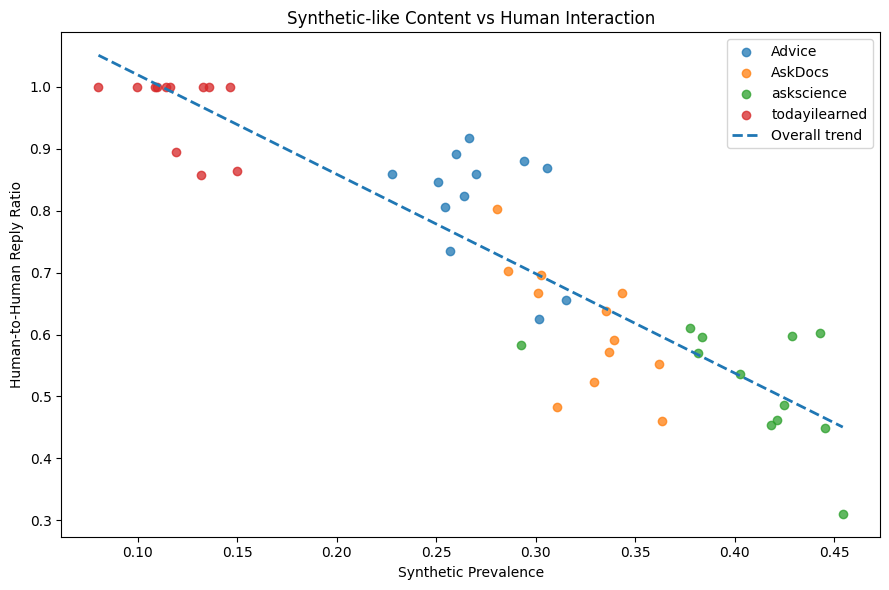

Analysis dataset preview:


,batch_id,subreddit,window_start,window_end,year_week,synthetic_prevalence,h2h_ratio
0,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W40,0.266344,0.916667
1,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W41,0.254102,0.805556
2,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W42,0.305626,0.869565
3,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W43,0.257000,0.735294
4,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W44,0.301392,0.625000
5,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W45,0.250725,0.846154
6,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W46,0.259768,0.892308
7,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W47,0.294031,0.880000
8,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W48,0.227871,0.860000
9,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,2025-W49,0.264081,0.823529



Regression formula used: h2h_ratio ~ synthetic_prevalence + C(subreddit)
                            OLS Regression Results                            
Dep. Variable:              h2h_ratio   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     67.88
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.15e-18
Time:                        19:05:38   Log-Likelihood:                 58.617
No. Observations:                  48   AIC:                            -107.2
Df Residuals:                      43   BIC:                            -97.88
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

In [15]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
INPUT_DIR = f"{PROJECT_ROOT}/input"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"
MODEL_DIR = f"{PROJECT_ROOT}/models"

# Check required files
required_files = [
    f"{OUTPUT_DIR}/combined_comments_clean_final.csv",
    f"{OUTPUT_DIR}/comment_embeddings.npy",
    f"{MODEL_DIR}/best_model.joblib",
    f"{MODEL_DIR}/tfidf_vectorizer.joblib",
    f"{MODEL_DIR}/model_metadata.json",
]

missing = [p for p in required_files if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "These required files are missing. Run the training cell first:\n" + "\n".join(missing)
    )

label_candidates = [
    f"{INPUT_DIR}/labeled_master.csv",
    f"{OUTPUT_DIR}/labeled_master.csv",
]
label_path = next((p for p in label_candidates if os.path.exists(p)), None)

comments_main = pd.read_csv(f"{OUTPUT_DIR}/combined_comments_clean_final.csv", low_memory=False)
comments_main["comment_id"] = comments_main["comment_id"].astype(str)

if "parent_comment_id" in comments_main.columns:
    comments_main["parent_comment_id"] = comments_main["parent_comment_id"].astype("string")

if label_path is not None:
    labels = pd.read_csv(label_path, low_memory=False)
    labels["comment_id"] = labels["comment_id"].astype(str)

    if "label" in labels.columns:
        labels = labels[["comment_id", "label"]].copy()
        labels["label"] = pd.to_numeric(labels["label"], errors="coerce")
        labels = labels.dropna(subset=["label"]).copy()
        labels["label"] = labels["label"].astype(int)
        labels = labels[labels["label"] != -1].drop_duplicates(subset=["comment_id"], keep="first")
        comments_main = comments_main.merge(labels, on="comment_id", how="left")
    else:
        comments_main["label"] = np.nan
else:
    comments_main["label"] = np.nan

best_model = joblib.load(f"{MODEL_DIR}/best_model.joblib")
tfidf = joblib.load(f"{MODEL_DIR}/tfidf_vectorizer.joblib")

with open(f"{MODEL_DIR}/model_metadata.json", "r") as f:
    metadata = json.load(f)

best_feature_type = metadata["best_feature_type"]

texts = comments_main["text"].fillna("").astype(str).tolist()
embeddings = np.load(f"{OUTPUT_DIR}/comment_embeddings.npy")
X_tfidf = tfidf.transform(texts)

if best_feature_type == "embeddings":
    full_X = embeddings
elif best_feature_type == "tfidf":
    full_X = X_tfidf
else:
    raise ValueError(f"Unknown feature type: {best_feature_type}")

synthetic_scores = best_model.predict_proba(full_X)[:, 1]
comments_main["synthetic_score"] = synthetic_scores
comments_main["is_synthetic_like"] = (comments_main["synthetic_score"] >= 0.5).astype(int)

comments_main.to_csv(f"{OUTPUT_DIR}/comments_scored.csv", index=False)

prevalence = (
    comments_main.groupby(
        ["batch_id", "subreddit", "window_start", "window_end", "year_week"],
        dropna=False
    )["synthetic_score"]
    .mean()
    .reset_index()
    .rename(columns={"synthetic_score": "synthetic_prevalence"})
)

parent_flags = comments_main[["comment_id", "is_synthetic_like"]].copy()
parent_flags.columns = ["parent_comment_id", "parent_is_synthetic_like"]
parent_flags["parent_comment_id"] = parent_flags["parent_comment_id"].astype("string")

with_parent = comments_main.merge(parent_flags, on="parent_comment_id", how="left")
replies = with_parent[with_parent["parent_comment_id"].notna()].copy()

replies["is_h2h"] = (
    (replies["is_synthetic_like"] == 0) &
    (replies["parent_is_synthetic_like"] == 0)
).astype(int)

h2h = (
    replies.groupby(
        ["batch_id", "subreddit", "window_start", "window_end", "year_week"],
        dropna=False
    )["is_h2h"]
    .mean()
    .reset_index()
    .rename(columns={"is_h2h": "h2h_ratio"})
)

analysis_df = prevalence.merge(
    h2h,
    on=["batch_id", "subreddit", "window_start", "window_end", "year_week"],
    how="inner"
)

analysis_df.to_csv(f"{OUTPUT_DIR}/analysis_dataset.csv", index=False)

print("Analysis dataset shape:", analysis_df.shape)

if analysis_df.empty:
    raise ValueError("analysis_df is empty. No valid subreddit-week rows survived the merge.")

plt.figure(figsize=(9, 6))
for subreddit, grp in analysis_df.groupby("subreddit"):
    plt.scatter(
        grp["synthetic_prevalence"],
        grp["h2h_ratio"],
        alpha=0.75,
        label=subreddit
    )

x = analysis_df["synthetic_prevalence"].to_numpy()
y = analysis_df["h2h_ratio"].to_numpy()

if len(analysis_df) >= 2 and np.unique(x).size > 1:
    m, b = np.polyfit(x, y, 1)
    x_sorted = np.sort(x)
    plt.plot(x_sorted, m * x_sorted + b, linestyle="--", linewidth=2, label="Overall trend")

plt.xlabel("Synthetic Prevalence")
plt.ylabel("Human-to-Human Reply Ratio")
plt.title("Synthetic-like Content vs Human Interaction")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/main_scatter.png", dpi=220)
plt.show()

reg_df = analysis_df.dropna().copy()

if len(reg_df) < 3:
    raise ValueError("Not enough rows for regression after dropping NaNs.")

formula = "h2h_ratio ~ synthetic_prevalence + C(subreddit)"
model = smf.ols(formula=formula, data=reg_df).fit()

with open(f"{OUTPUT_DIR}/regression_summary.txt", "w") as f:
    f.write(model.summary().as_text())

print("Analysis dataset preview:")
display(analysis_df.head(20))

print("\nRegression formula used:", formula)
print(model.summary())

print("\nSaved:")
print(f"{OUTPUT_DIR}/comments_scored.csv")
print(f"{OUTPUT_DIR}/analysis_dataset.csv")
print(f"{OUTPUT_DIR}/main_scatter.png")
print(f"{OUTPUT_DIR}/regression_summary.txt")

In [13]:
audit_df = pd.read_csv(f"{OUTPUT_DIR}/batch_audit.csv")
results_df = pd.read_csv(f"{OUTPUT_DIR}/model_results.csv") if os.path.exists(f"{OUTPUT_DIR}/model_results.csv") else None
analysis_df = pd.read_csv(f"{OUTPUT_DIR}/analysis_dataset.csv") if os.path.exists(f"{OUTPUT_DIR}/analysis_dataset.csv") else None

print("Batch audit")
display(audit_df)

if results_df is not None:
    print("\nModel results")
    display(results_df)

if analysis_df is not None:
    print("\nAnalysis rows per subreddit")
    display(
        analysis_df.groupby("subreddit").size().reset_index(name="n_rows")
    )

    print("\nAverage synthetic prevalence and h2h ratio by subreddit")
    display(
        analysis_df.groupby("subreddit")[["synthetic_prevalence", "h2h_ratio"]]
        .mean()
        .reset_index()
    )

Batch audit


,batch_id,subreddit,window_start,window_end,tag,raw_comments,excluded_comments,template_removed_comments,meta_removed_comments,final_clean_comments,retention_pct,anchor_posts,posts_with_retained_comments,comment_to_comment_replies,direct_post_replies,reply_chain_share_pct,parent_post_found_rate_pct,weeks_present
0,Advice__20251006__20251228__weekbalanced,Advice,20251006,20251228,weekbalanced,3600,93,1,0.0,2498,69.39,917,765,435,2063,17.41,92.95,12
1,AskDocs__20251006__20251228__weekbalanced,AskDocs,20251006,20251228,weekbalanced,6100,2834,3,42.0,1572,25.77,977,596,819,753,52.10,97.33,12
2,askscience__20251006__20251228__weekbalanced,askscience,20251006,20251228,weekbalanced,6600,3287,2,NaN,2541,38.50,190,153,1744,797,68.63,100.00,12
3,todayilearned__20251006__20251228__weekbalanced,todayilearned,20251006,20251228,weekbalanced,3600,122,1,3.0,995,27.64,371,230,213,782,21.41,92.26,12



Model results


,pipeline,accuracy,f1,roc_auc,feature_type
0,Embeddings + LR,0.817164,0.328767,0.849111,embeddings
1,Embeddings + XGB,0.936567,0.260870,0.825111,embeddings
2,TF-IDF + LR,0.925373,0.166667,0.776444,tfidf
3,TF-IDF + XGB,0.921642,0.086957,0.673000,tfidf



Analysis rows per subreddit


,subreddit,n_rows
0,Advice,12
1,AskDocs,12
2,askscience,12
3,todayilearned,12



Average synthetic prevalence and h2h ratio by subreddit


,subreddit,synthetic_prevalence,h2h_ratio
0,Advice,0.272187,0.814151
1,AskDocs,0.324120,0.612821
2,askscience,0.406113,0.521592
3,todayilearned,0.120414,0.967960


In [14]:
print("Quick pilot summary")
print("-" * 40)

print("\nBest model:")
display(results_df.head(1))

print("\nSubreddit-week counts:")
display(analysis_df.groupby("subreddit").size().reset_index(name="weeks"))

print("\nAverage weekly metrics by subreddit:")
display(
    analysis_df.groupby("subreddit")[["synthetic_prevalence", "h2h_ratio"]]
    .agg(["mean", "min", "max"])
    .round(4)
)

print("\nOverall correlation:")
print(
    analysis_df[["synthetic_prevalence", "h2h_ratio"]]
    .corr()
)

Quick pilot summary
----------------------------------------

Best model:


,pipeline,accuracy,f1,roc_auc,feature_type
0,Embeddings + LR,0.817164,0.328767,0.849111,embeddings



Subreddit-week counts:


,subreddit,weeks
0,Advice,12
1,AskDocs,12
2,askscience,12
3,todayilearned,12



Average weekly metrics by subreddit:


synthetic_prevalence                 h2h_ratio                
                              mean     min     max      mean     min     max
subreddit                                                                   
Advice                      0.2722  0.2279  0.3151    0.8142  0.6250  0.9167
AskDocs                     0.3241  0.2804  0.3633    0.6128  0.4605  0.8025
askscience                  0.4061  0.2925  0.4542    0.5216  0.3103  0.6105
todayilearned               0.1204  0.0803  0.1496    0.9680  0.8571  1.0000


Overall correlation:
                      synthetic_prevalence  h2h_ratio
synthetic_prevalence              1.000000  -0.900923
h2h_ratio                        -0.900923   1.000000


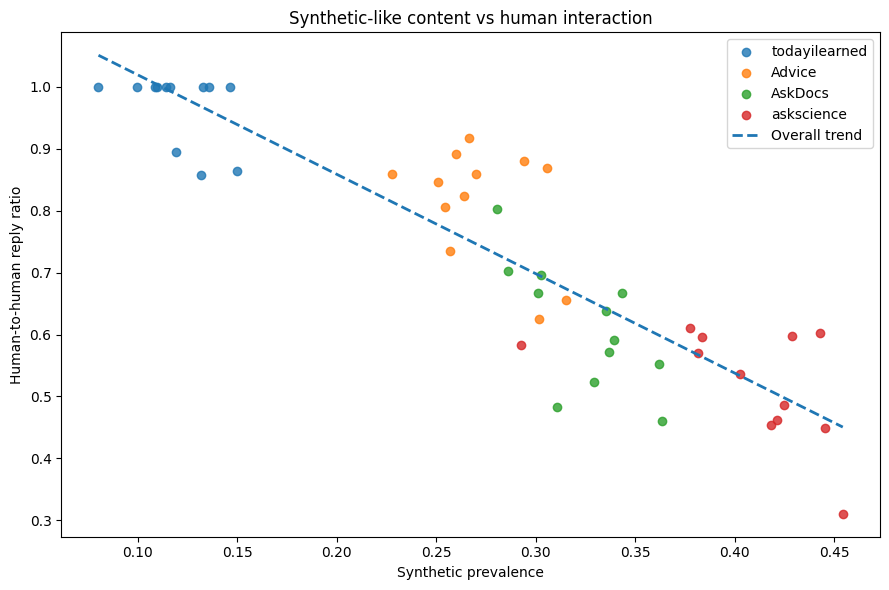

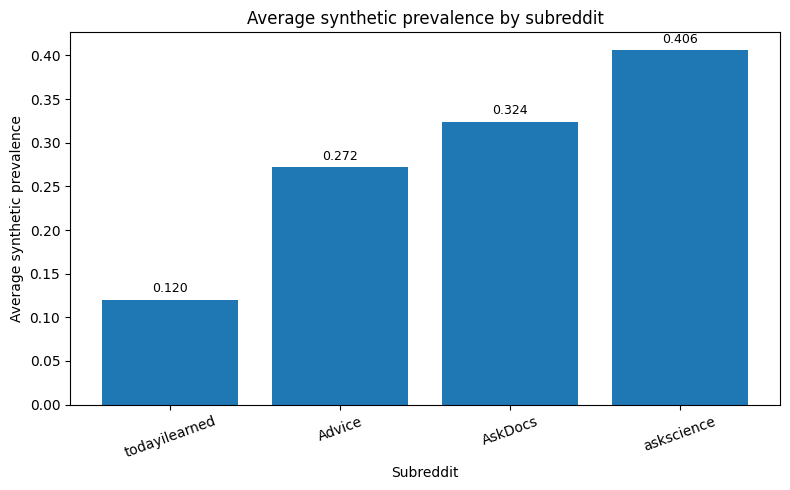

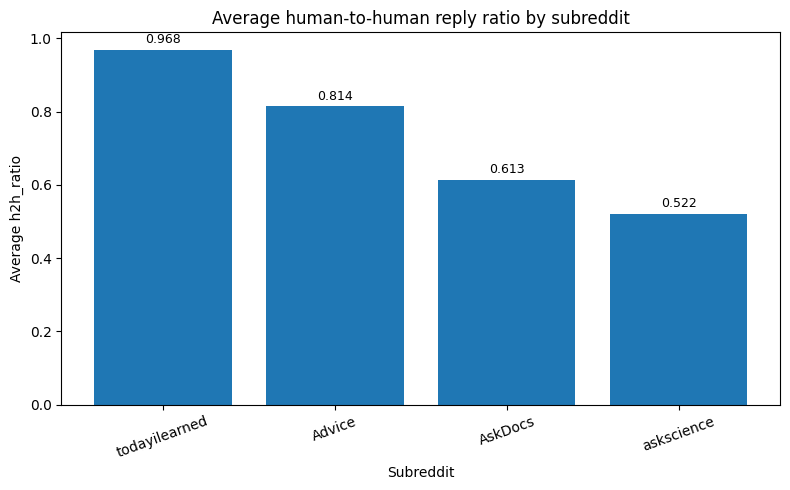

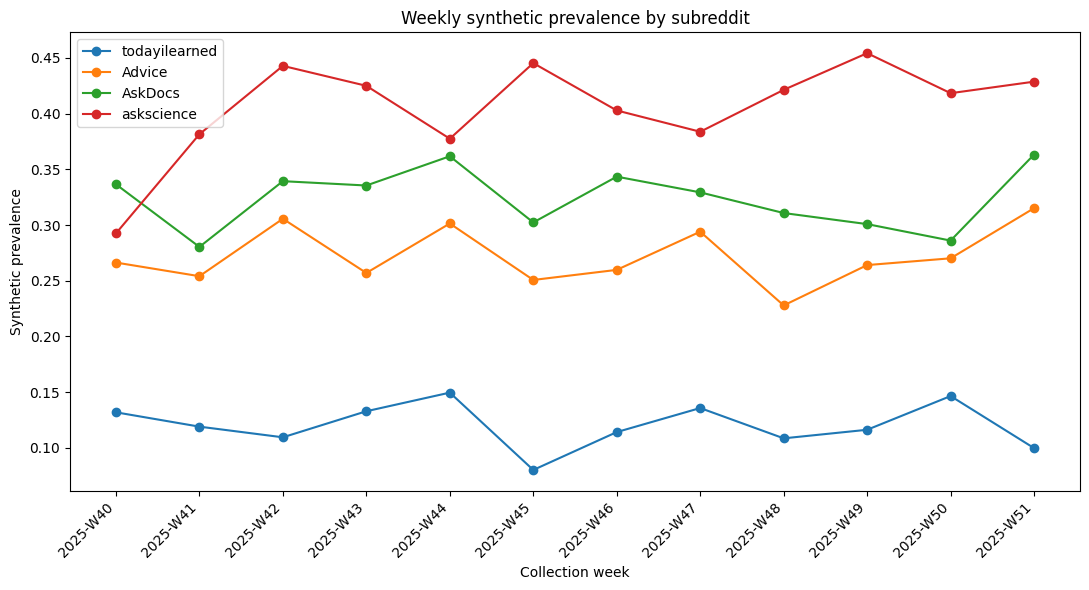

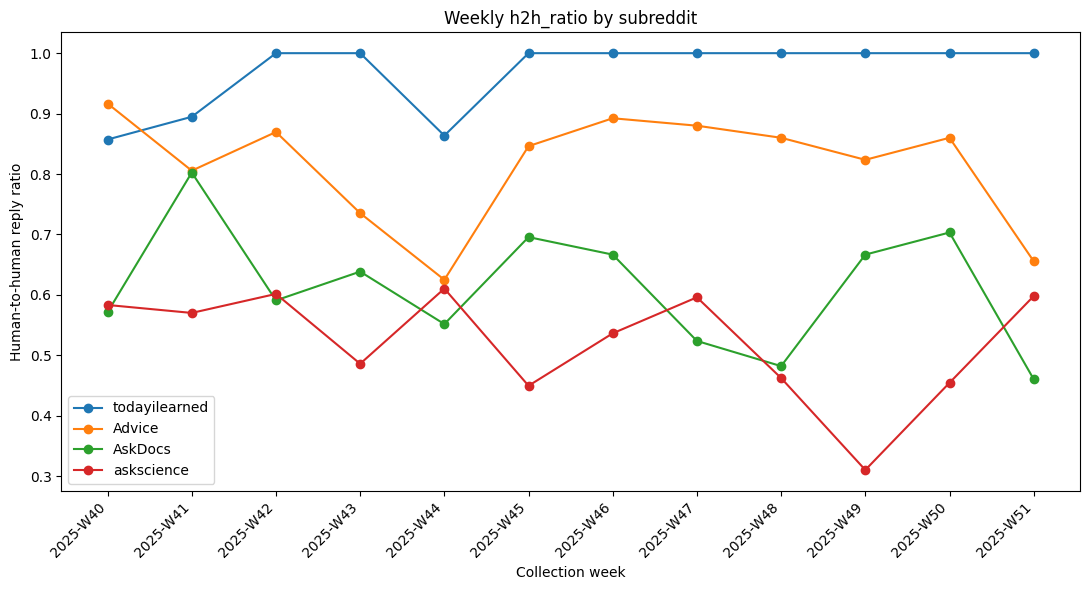

Saved figures:
/content/drive/MyDrive/reddit_ai_study/output/figure_scatter_synthetic_vs_h2h.png
/content/drive/MyDrive/reddit_ai_study/output/figure_bar_avg_synthetic_prevalence.png
/content/drive/MyDrive/reddit_ai_study/output/figure_bar_avg_h2h_ratio.png
/content/drive/MyDrive/reddit_ai_study/output/figure_weekly_synthetic_prevalence.png
/content/drive/MyDrive/reddit_ai_study/output/figure_weekly_h2h_ratio.png


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load analysis data from memory if available; otherwise from disk
# --------------------------------------------------
PROJECT_ROOT = "/content/drive/MyDrive/reddit_ai_study"
OUTPUT_DIR = f"{PROJECT_ROOT}/output"

if "analysis_df" not in globals():
    analysis_df = pd.read_csv(f"{OUTPUT_DIR}/analysis_dataset.csv")

analysis_df = analysis_df.copy()

# Make sure types are clean
analysis_df["synthetic_prevalence"] = pd.to_numeric(analysis_df["synthetic_prevalence"], errors="coerce")
analysis_df["h2h_ratio"] = pd.to_numeric(analysis_df["h2h_ratio"], errors="coerce")
analysis_df["year_week"] = analysis_df["year_week"].astype(str)

# Common subreddit order: sorted by mean synthetic prevalence (low -> high)
subreddit_order = (
    analysis_df.groupby("subreddit")["synthetic_prevalence"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

# Common week order
week_order = sorted(analysis_df["year_week"].dropna().unique().tolist())

# --------------------------------------------------
# 1) Scatter plot: synthetic_prevalence vs h2h_ratio
# --------------------------------------------------
plt.figure(figsize=(9, 6))
for subreddit in subreddit_order:
    grp = analysis_df[analysis_df["subreddit"] == subreddit].sort_values("year_week")
    plt.scatter(
        grp["synthetic_prevalence"],
        grp["h2h_ratio"],
        alpha=0.8,
        label=subreddit
    )

x = analysis_df["synthetic_prevalence"].to_numpy()
y = analysis_df["h2h_ratio"].to_numpy()

if len(analysis_df) >= 2 and np.unique(x).size > 1:
    m, b = np.polyfit(x, y, 1)
    x_sorted = np.sort(x)
    plt.plot(x_sorted, m * x_sorted + b, linestyle="--", linewidth=2, label="Overall trend")

plt.xlabel("Synthetic prevalence")
plt.ylabel("Human-to-human reply ratio")
plt.title("Synthetic-like content vs human interaction")
plt.legend()
plt.tight_layout()
scatter_path = f"{OUTPUT_DIR}/figure_scatter_synthetic_vs_h2h.png"
plt.savefig(scatter_path, dpi=220, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 2) Bar chart: average synthetic prevalence by subreddit
# --------------------------------------------------
avg_prev = (
    analysis_df.groupby("subreddit")["synthetic_prevalence"]
    .mean()
    .reindex(subreddit_order)
)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_prev.index, avg_prev.values)
plt.xlabel("Subreddit")
plt.ylabel("Average synthetic prevalence")
plt.title("Average synthetic prevalence by subreddit")
plt.xticks(rotation=20)

for bar, val in zip(bars, avg_prev.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
bar_prev_path = f"{OUTPUT_DIR}/figure_bar_avg_synthetic_prevalence.png"
plt.savefig(bar_prev_path, dpi=220, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 3) Bar chart: average h2h_ratio by subreddit
# --------------------------------------------------
avg_h2h = (
    analysis_df.groupby("subreddit")["h2h_ratio"]
    .mean()
    .reindex(subreddit_order)
)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_h2h.index, avg_h2h.values)
plt.xlabel("Subreddit")
plt.ylabel("Average h2h_ratio")
plt.title("Average human-to-human reply ratio by subreddit")
plt.xticks(rotation=20)

for bar, val in zip(bars, avg_h2h.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
bar_h2h_path = f"{OUTPUT_DIR}/figure_bar_avg_h2h_ratio.png"
plt.savefig(bar_h2h_path, dpi=220, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 4) Weekly trend lines: synthetic prevalence by subreddit
# --------------------------------------------------
plt.figure(figsize=(11, 6))
for subreddit in subreddit_order:
    grp = (
        analysis_df[analysis_df["subreddit"] == subreddit]
        .set_index("year_week")
        .reindex(week_order)
        .reset_index()
    )
    plt.plot(
        grp["year_week"],
        grp["synthetic_prevalence"],
        marker="o",
        label=subreddit
    )

plt.xlabel("Collection week")
plt.ylabel("Synthetic prevalence")
plt.title("Weekly synthetic prevalence by subreddit")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
trend_prev_path = f"{OUTPUT_DIR}/figure_weekly_synthetic_prevalence.png"
plt.savefig(trend_prev_path, dpi=220, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 5) Weekly trend lines: h2h_ratio by subreddit
# --------------------------------------------------
plt.figure(figsize=(11, 6))
for subreddit in subreddit_order:
    grp = (
        analysis_df[analysis_df["subreddit"] == subreddit]
        .set_index("year_week")
        .reindex(week_order)
        .reset_index()
    )
    plt.plot(
        grp["year_week"],
        grp["h2h_ratio"],
        marker="o",
        label=subreddit
    )

plt.xlabel("Collection week")
plt.ylabel("Human-to-human reply ratio")
plt.title("Weekly h2h_ratio by subreddit")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
trend_h2h_path = f"{OUTPUT_DIR}/figure_weekly_h2h_ratio.png"
plt.savefig(trend_h2h_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(scatter_path)
print(bar_prev_path)
print(bar_h2h_path)
print(trend_prev_path)
print(trend_h2h_path)